<a href="https://colab.research.google.com/github/Gchirico63/Didattica/blob/main/PhysicalPropagation/Aberrations/Astigmatism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import matplotlib.pyplot as plt
import numpy as np

#####   Astigmatism aberration
#####   19 MArch 2025
#####    G. Chirico
#### Seidel Coefficients for thin lenses
#### from Hecht

def C20(f,n,S):
    ### f is the focal length
    ### S = Sprime, position of the image plane
    ### n is the RI

    return -(n+1)/4/n/f/S/S

def C22(f,S):
    return -1/2/f/S/S

def B0X(c22,c20,xprime,Sprime,n):
    return 2*(c22+c20)*Sprime*xprime**2/n

def B0Y(c20,xprime,Sprime,n):
    return 2*(c20)*Sprime*xprime**2/n

pupil   = 20  # mm
R1      = 100  ## mm
R2      = -R1
RI      = 1.5

f       = 1/((RI-1)*(1/R1-1/R2))
q       = (R2+R1)/(R2-R1)

Sprime  = 100 ### 2.2*f ## mm
p       = 1 - 2*f/Sprime
xprime  = 20 #mm

c22     = C20(f,RI,Sprime)
c20     = C22(f,Sprime)

b0x     = B0X(c22,c20,xprime,Sprime,RI)
b0y     = B0Y(c20,xprime,Sprime,RI)

lsa_T   = Sprime * b0x
lsa_S   = Sprime * b0y

print ('focal length=',round(f,3),' mm; \n p factor=',p,'; \n q factor=',q,';')
print ('C20 = ',c20,' 1/mm^3')
print ('c22 = ',c22,' 1/mm^3 ')
print ('lsa_tang.=',lsa_T,' mm')
print ('lsa_sagg=',lsa_S,' mm')
print ('xprime = ',xprime,' [mm]')
print ('Sprime = ',Sprime,' [mm]')

x       = np.linspace(pupil*0.00001,pupil,100)


focal length= 100.0  mm; 
 p factor= -1.0 ; 
 q factor= -0.0 ;
C20 =  -5e-07  1/mm^3
c22 =  -4.1666666666666667e-07  1/mm^3 
lsa_tang.= -4.888888888888889  mm
lsa_sagg= -2.666666666666666  mm
xprime =  20  [mm]
Sprime =  100  [mm]


DeltaS,B_X,B_Y   
-2.0 -0.03 -0.01
-2.25 -0.03 -0.0
-2.5 -0.02 -0.0
-2.75 -0.02 0.0
-3.0 -0.02 0.0
-3.25 -0.02 0.01
-3.5 -0.01 0.01
-3.75 -0.01 0.01
-4.0 -0.01 0.01
-4.25 -0.01 0.02
-4.5 -0.0 0.02
-4.75 -0.0 0.02
-5.0 0.0 0.02
-5.25 0.0 0.03
-5.5 0.01 0.03
-5.75 0.01 0.03


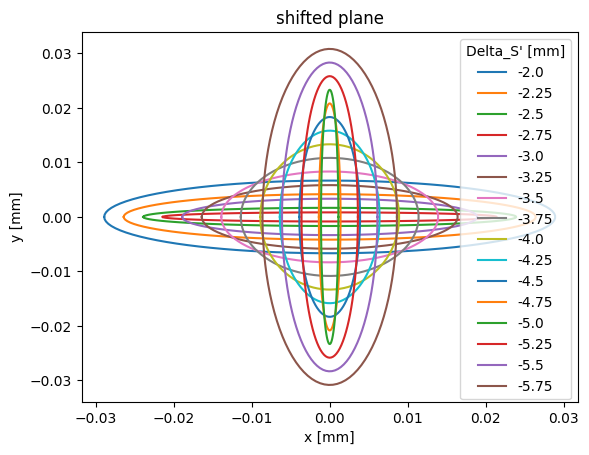

In [23]:
plt.figure()
print('DeltaS,B_X,B_Y   ')

for DeltaS in np.arange(-2,-6,-0.25):
  BX = b0x - DeltaS/Sprime
  BY = b0y - DeltaS/Sprime

  # Generate points for the ellipse
  theta = np.linspace(0, 2 * np.pi, 100)
  x = BX * np.cos(theta)
  y = BY * np.sin(theta)
  print(DeltaS,np.round(BX,2),np.round(BY,2))
  plt.plot(x,y,label=str(DeltaS))
legend = plt.legend()
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.title('shifted plane')
legend.set_title("Delta_S' [mm]")